In [1]:
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the cleaned dataset
df = pd.read_excel("Cleaned_Sales_Dataset.xlsx")

In [4]:
print(df.head())

print(df.info())

print(df['Gender'].value_counts())

    Order_ID Order_Date Customer_ID Customer_Name  Age  Gender       City  \
0  ORD100002 2025-02-25    CUST5529  Customer_227   30  Female  Bengaluru   
1  ORD100003 2025-10-14    CUST3127  Customer_182   63    Male  Bengaluru   
2  ORD100004 2025-05-13    CUST8887  Customer_487   62  Female  Bengaluru   
3  ORD100005 2025-12-02    CUST2515  Customer_470   65  Female    Kolkata   
4  ORD100006 2025-11-20    CUST4796  Customer_380   44    Male  Bengaluru   

  Product     Category  Quantity  Unit_Price  Total_Sales  Year     Month  \
0    Rice      Grocery         7     2829.77     19808.39  2025  February   
1    Book    Education         5    27906.16    139530.80  2025   October   
2    Book    Education         8    37491.06    299928.48  2025       May   
3  Mobile  Electronics         9    28541.36    256872.24  2025  December   
4    Rice      Grocery        10    14036.59    140365.90  2025  November   

   Quarter       Day    Age_Group  
0        1   Tuesday  Young Adult  
1 

In [5]:
male_sales = df[df["Gender"] == "Male"]["Total_Sales"]

female_sales = df[df["Gender"] == "Female"]["Total_Sales"]

In [6]:
print("Male Customers")
print(male_sales.describe())

print()

print("Female Customers")
print(female_sales.describe())

Male Customers
count       511.000000
mean     141807.339785
std      116327.975385
min         437.340000
25%       47543.825000
50%      109237.860000
75%      218334.380000
max      493677.500000
Name: Total_Sales, dtype: float64

Female Customers
count       489.000000
mean     136883.208630
std      111788.031275
min        1005.210000
25%       45270.450000
50%      108470.600000
75%      197341.680000
max      490866.400000
Name: Total_Sales, dtype: float64


In [7]:
t_stat, p_value = ttest_ind(
    male_sales,
    female_sales,
    equal_var=False
)

print("T Statistic :", round(t_stat,4))
print("P Value :", round(p_value,4))

T Statistic : 0.6826
P Value : 0.495


In [8]:
alpha = 0.05

print("\nHypothesis Testing")

if p_value < alpha:
    print("Reject the Null Hypothesis (H₀)")
    print("There is a statistically significant difference in average spending between male and female customers.")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")
    print("There is no statistically significant difference in average spending between male and female customers.")


Hypothesis Testing
Fail to Reject the Null Hypothesis (H₀)
There is no statistically significant difference in average spending between male and female customers.


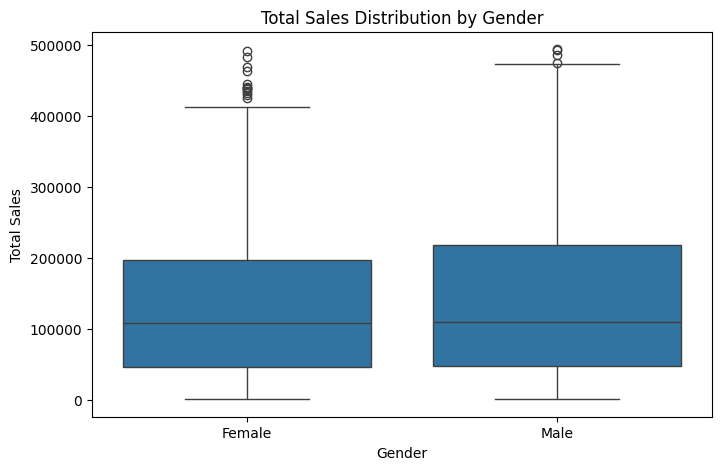

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Gender",
    y="Total_Sales",
    data=df
)

plt.title("Total Sales Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.show()

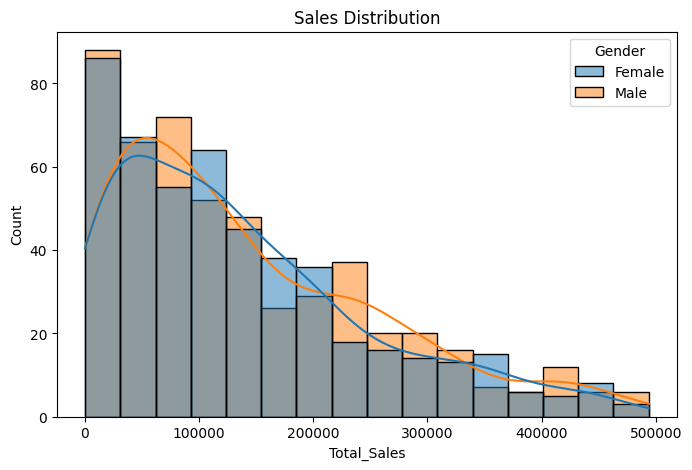

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Total_Sales",
    hue="Gender",
    kde=True
)

plt.title("Sales Distribution")
plt.show()